In [2]:
import sys
import torch
import transformers
import datasets
import sklearn
import pandas as pd

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("Pandas:", pd.__version__)

print("\nGPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

d:\Programs\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]
PyTorch: 2.14.0+cu132
Transformers: 5.17.0
Datasets: 5.0.1
Pandas: 3.0.6

GPU available: True
GPU: NVIDIA GeForce GTX 1650 with Max-Q Design


In [3]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.14.0+cu132
CUDA available: True
CUDA version: 13.2
GPU: NVIDIA GeForce GTX 1650 with Max-Q Design


In [4]:
import torch

x = torch.rand(5000, 5000).cuda()
y = torch.rand(5000, 5000).cuda()

z = x @ y

print("Tensor device:", z.device)
print("GPU:", torch.cuda.get_device_name(0))

Tensor device: cuda:0
GPU: NVIDIA GeForce GTX 1650 with Max-Q Design


In [5]:
from datasets import load_dataset

dataset = load_dataset("fancyzhx/amazon_polarity")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 3600000
    })
    test: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 400000
    })
})


In [6]:
print(f"Training sample: {len(dataset['train'])}")
print(f"Testing sample: {len(dataset['test'])}")

Training sample: 3600000
Testing sample: 400000


In [7]:
print(dataset["train"][0])

{'label': 1, 'title': 'Stuning even for the non-gamer', 'content': 'This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^'}


In [8]:
print(dataset["train"].features)

{'label': ClassLabel(names=['negative', 'positive']), 'title': Value('string'), 'content': Value('string')}


In [9]:
print(dataset["train"].features["label"])

ClassLabel(names=['negative', 'positive'])


In [10]:
sample = dataset["train"][0]

print("Label:", sample["label"])
print("Title:", sample["title"])
print("Review:")
print(sample["content"])

Label: 1
Title: Stuning even for the non-gamer
Review:
This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^


In [11]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 3600000
    })
    test: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 400000
    })
})


In [12]:
print("Train columns:", dataset["train"].column_names)
print("Test columns:", dataset["test"].column_names)

print("Train size:", len(dataset["train"]))
print("Test size:", len(dataset["test"]))

Train columns: ['label', 'title', 'content']
Test columns: ['label', 'title', 'content']
Train size: 3600000
Test size: 400000


In [13]:
from collections import Counter

train_labels = Counter(dataset["train"]["label"])
test_labels = Counter(dataset["test"]["label"])

print("Training label distribution:")
print(train_labels)

print("\nTesting label distribution:")
print(test_labels)

Training label distribution:
Counter({1: 1800000, 0: 1800000})

Testing label distribution:
Counter({1: 200000, 0: 200000})


In [14]:
train_data = dataset["train"]

print(f"Number of samples: {len(train_data)}")

print(f"Missing titles: {sum(1 for x in train_data['title'] if x is None)}")
print(f"Missing reviews: {sum(1 for x in train_data['content'] if x is None)}")

print(f"Empty titles: {sum(1 for x in train_data['title'] if x.strip() == "")}")
print(f"Empty reviews: {sum(1 for x in train_data['content'] if x.strip() == "")}")

Number of samples: 3600000
Missing titles: 0
Missing reviews: 0
Empty titles: 48
Empty reviews: 0


In [15]:
sample_data = train_data.shuffle(seed=42).select(range(10000))

reviews = [
    f"{title} {content}"
    for title, content in zip(sample_data["title"], sample_data["content"])
]

print(f"Sample review: {len(reviews)}")
print(f"Unique reviews: {len(set(reviews))}")
print(f"Duplicate reviews: {len(reviews) - len(set(reviews))}")

Sample review: 10000
Unique reviews: 10000
Duplicate reviews: 0


In [16]:
import numpy as np

review_lengths = np.array([
    len(review.split())
    for review in sample_data["content"]
])

print(f"Minimum review length: {review_lengths.min()}")
print(f"Maximum review length: {review_lengths.max()}")
print(f"Average review length: {review_lengths.mean():.2f}")
print(f"Median review length: {np.median(review_lengths):.2f}")

Minimum review length: 4
Maximum review length: 210
Average review length: 73.84
Median review length: 66.00


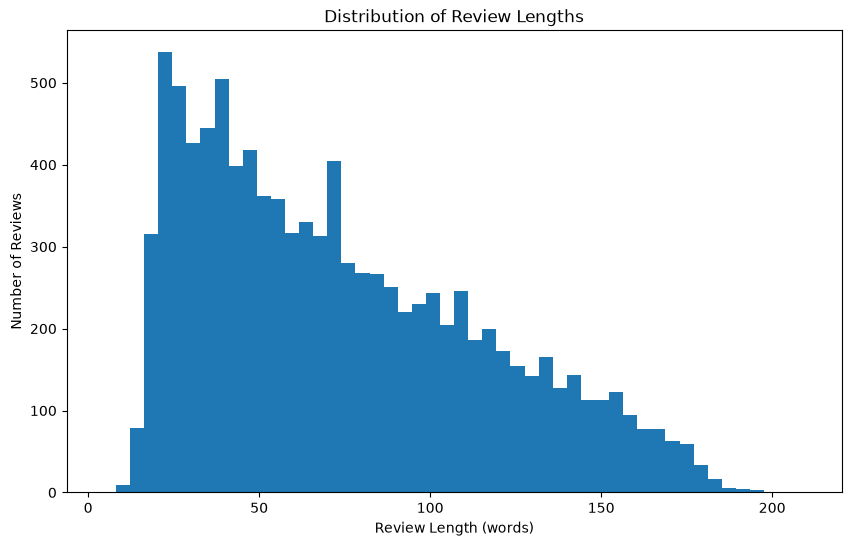

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(review_lengths, bins=50)
plt.xlabel("Review Length (words)")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Lengths")

plt.show()

In [18]:
percentiles = np.percentile(
    review_lengths,
    [25, 50, 75, 90, 95, 99]
)

for percentile, value in zip(
    [25, 50, 75, 90, 95, 99],
    percentiles
):
    print(f"{percentile}th percentile: {value:.0f} words")

25th percentile: 39 words
50th percentile: 66 words
75th percentile: 103 words
90th percentile: 137 words
95th percentile: 154 words
99th percentile: 174 words


In [20]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

sample_text = [f"{title} {content}" for title, content in zip(sample_data["title"], sample_data["content"])]
total_lengths = [len(tokenizer.encode(text, add_special_tokens=True)) for text in sample_text]

token_lengths = np.array(total_lengths)

print(f"Minimum token length: {token_lengths.min()}")
print(f"Maximum token length: {token_lengths.max()}")
print(f"Average token length: {token_lengths.mean():.2f}")
print(f"Median token length: {np.median(token_lengths):.0f}")

Minimum token length: 20
Maximum token length: 292
Average token length: 101.04
Median token length: 90


In [21]:
percentiles = np.percentile(
    token_lengths,
    [25, 50, 75, 90, 95, 99]
)

for percentile, value in zip(
    [25, 50, 75, 90, 95, 99],
    percentiles
):
    print(f"{percentile}th percentile: {value:.0f} tokens")

25th percentile: 56 tokens
50th percentile: 90 tokens
75th percentile: 138 tokens
90th percentile: 184 tokens
95th percentile: 205 tokens
99th percentile: 234 tokens


In [22]:
from datasets import concatenate_datasets

positive_train = dataset["train"].filter(lambda x: x["label"] == 1)
negative_train = dataset["train"].filter(lambda x: x["label"] == 0)

positive_test = dataset["test"].filter(lambda x: x["label"] == 1)
negative_test = dataset["test"].filter(lambda x: x["label"] == 0)


print(f"Positive training reviews: {len(positive_train)}")
print(f"Negative training reviews: {len(negative_train)}")
print(f"Positive test reviews: {len(positive_test)}")
print(f"Negative test reviews: {len(negative_test)}")

Filter: 100%|██████████| 400000/400000 [00:00<00:00, 591248.15 examples/s]

Positive training reviews: 1800000
Negative training reviews: 1800000
Positive test reviews: 200000
Negative test reviews: 200000


In [23]:
train_positive = positive_train.shuffle(seed=42).select(range(25000))
train_negative = negative_train.shuffle(seed=42).select(range(25000))

test_positive = positive_test.shuffle(seed=42).select(range(5000))
test_negative = negative_test.shuffle(seed=42).select(range(5000))

train_subset = concatenate_datasets([train_positive, train_negative]).shuffle(seed=42)
test_subset = concatenate_datasets([test_positive, test_negative]).shuffle(seed=42)

print(f"Training subset size: {len(train_subset)}")
print(f"Test subset size: {len(test_subset)}")

Training subset size: 50000
Test subset size: 10000


In [24]:
validation_positive = positive_train.shuffle(seed=123).select(range(5000))
validation_negative = negative_train.shuffle(seed=123).select(range(5000))

validation_subset = concatenate_datasets([
    validation_positive,
    validation_negative
]).shuffle(seed=123)

print(f"Validation subset size: {len(validation_subset)}")

Validation subset size: 10000


In [25]:
def combine_text(example):
    title = example["title"].strip()
    content = example["content"].strip()
    
    if title: 
        example["text"] = f"{title}. {content}"
    else:
        example["text"] = content
        
    return example

In [27]:
train_subset = train_subset.map(combine_text)
validation_subset = validation_subset.map(combine_text)
test_subset = test_subset.map(combine_text)

Map: 100%|██████████| 10000/10000 [00:03<00:00, 2843.00 examples/s]


In [28]:
sample = train_subset[0]

print(f"Label: {sample['label']}")
print(f"Title: {sample['title']}")
print(f"Combined text:\n{sample['text']}")

Label: 1
Title: Perfect
Combined text:
Perfect. I've had my 80 GB Classic in this thing for over a year with absolutely no problems. I take it everywhere and the case and iPod still look brand new. This thing isn't going to protect your iPod from careless abuse, but it does offer sufficient protection for ordinary use.


In [29]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

print(f"Tokenizer vocabulary size: {tokenizer.vocab_size}")

Tokenizer vocabulary size: 30522


In [30]:
sample_text = train_subset[0]["text"]

tokens = tokenizer(
    sample_text,
    max_length=192,
    padding="max_length",
    truncation=True
)

print(f"Number of input IDs: {len(tokens['input_ids'])}")
print(f"Number of attention mask values: {len(tokens['attention_mask'])}")
print(f"First 20 input IDs: {tokens['input_ids'][:20]}")
print(f"First 20 attention mask values: {tokens['attention_mask'][:20]}")

Number of input IDs: 192
Number of attention mask values: 192
First 20 input IDs: [101, 3819, 1012, 1045, 1005, 2310, 2018, 2026, 3770, 16351, 4438, 1999, 2023, 2518, 2005, 2058, 1037, 2095, 2007, 7078]
First 20 attention mask values: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [31]:
real_tokens = sum(tokens["attention_mask"])

print(f"Actual tokens in sample: {real_tokens}")
print(f"Padding tokens: {192 - real_tokens}")

Actual tokens in sample: 62
Padding tokens: 130


In [32]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        max_length=192,
        padding="max_length",
        truncation=True
    )

In [33]:
tokenized_train = train_subset.map(tokenize_function, batched=True)
tokenized_validation = validation_subset.map(tokenize_function, batched=True)
tokenized_test = test_subset.map(tokenize_function, batched=True)

Map: 100%|██████████| 10000/10000 [00:01<00:00, 8351.60 examples/s]


In [34]:
print(f"Training samples: {len(tokenized_train)}")
print(f"Validation samples: {len(tokenized_validation)}")
print(f"Testing samples: {len(tokenized_test)}")

print(f"Training columns: {tokenized_train.column_names}")

Training samples: 50000
Validation samples: 10000
Testing samples: 10000
Training columns: ['label', 'title', 'content', 'text', 'input_ids', 'token_type_ids', 'attention_mask']


In [35]:
import torch 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce GTX 1650 with Max-Q Design


In [36]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
model.to(device)

print(f"Model device: {next(model.parameters()).device}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 625.22it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoin

Model device: cuda:0


In [37]:
colums_to_remove = ["title", "content", "text"]

tokenized_train = tokenized_train.remove_columns(colums_to_remove)
tokenized_validation = tokenized_validation.remove_columns(colums_to_remove)
tokenized_test = tokenized_test.remove_columns(colums_to_remove)

print(f"Training colums: {tokenized_train.column_names}")

Training colums: ['label', 'input_ids', 'token_type_ids', 'attention_mask']


In [38]:
tokenized_train.set_format("torch")
tokenized_validation.set_format("torch")
tokenized_test.set_format("torch")

In [39]:
sample = tokenized_train[0]

print(f"Input IDs shape: {sample['input_ids'].shape}")
print(f"Attention mask shape: {sample['attention_mask'].shape}")
print(f"Label: {sample['label']}")

Input IDs shape: torch.Size([192])
Attention mask shape: torch.Size([192])
Label: 1


In [40]:
from pathlib import Path

output_dir = Path("data/tokenized")
output_dir.mkdir(parents=True, exist_ok=True)

tokenized_train.save_to_disk(str(output_dir / "train"))
tokenized_validation.save_to_disk(str(output_dir / "validation"))
tokenized_test.save_to_disk(str(output_dir / "test"))

print(f"Tokenized datasets saved to: {output_dir.resolve()}")

Saving the dataset (1/1 shards): 100%|██████████| 10000/10000 [00:00<00:00, 162221.59 examples/s]

Tokenized datasets saved to: D:\Study\Data Science\Claude\Amazon-Review-Sentiment-Analyzer\notebooks\data\tokenized
